# Dynamic Programming and LQR

## 1. Why Dynamic Programming?

In the previous notebook, we solved optimal control problems using **Direct Methods**.

The basic idea was:

$$
\text{continuous optimal control problem}
\rightarrow
\text{discretization}
\rightarrow
\text{finite-dimensional optimization problem}
$$

Both the states and controls over the complete horizon were treated as optimization variables.

Now we will look at the problem from a different perspective.

Instead of asking:

> What is the optimal complete trajectory?

we ask:

> If I am at a particular state right now, what is the best decision from this state onward?

This idea leads to **Dynamic Programming (DP)**.

We will first understand DP using a very small discrete control problem, where we can inspect every possible solution.

Later, we will connect the same idea to **Linear Quadratic Regulation (LQR)** and use it for a vehicle path-tracking problem.

## 2. A Small Finite-Horizon Control Problem

Consider a simple 1D system:

$$
x_{k+1} = x_k + u_k
$$

where:

- $x_k$ is the position at timestep $k$
- $u_k$ is the control action

The available controls are deliberately restricted to:

$$
u_k \in \{-1,0,+1\}
$$

We start from:

$$
x_0 = 0
$$

and want to reach:

$$
x_{\text{goal}} = 2
$$

using a horizon of:

$$
N = 3
$$

Therefore, we can make three decisions:

$$
u_0,\;u_1,\;u_2
$$

which generate the state sequence:

$$
x_0 \rightarrow x_1 \rightarrow x_2 \rightarrow x_3
$$

### Defining the Objective

We do not only want to reach the goal. We also want to avoid unnecessary control effort.

We therefore define the cost:

$$
J =
\sum_{k=0}^{N-1} u_k^2
+
10(x_N-x_{\text{goal}})^2
$$

The first term,

$$
\sum_{k=0}^{N-1}u_k^2,
$$

penalizes control effort.

The second term,

$$
10(x_N-x_{\text{goal}})^2,
$$

penalizes terminal position error.

So the control problem is:

$$
\boxed{
\min_{u_0,u_1,u_2}
\left[
\sum_{k=0}^{2}u_k^2
+
10(x_3-2)^2
\right]
}
$$

subject to:

$$
x_{k+1}=x_k+u_k.
$$

## 3. First Approach — Brute Force

Before introducing Dynamic Programming, consider the most straightforward solution.

At every timestep we have three possible actions:

$$
\{-1,0,+1\}
$$

and we make three decisions.

Therefore, the total number of possible control sequences is:

$$
3^3 = 27.
$$

For example:

$$
(1,1,0)
$$

produces:

$$
0 \rightarrow 1 \rightarrow 2 \rightarrow 2.
$$

Its cost is:

$$
J = 1^2 + 1^2 + 0^2 + 10(2-2)^2 = 2.
$$

Another sequence,

$$
(1,0,0),
$$

produces:

$$
0 \rightarrow 1 \rightarrow 1 \rightarrow 1
$$

with cost:

$$
J = 1^2 + 0^2 + 0^2 + 10(1-2)^2 = 11.
$$

For this small problem, we can simply evaluate all 27 possibilities and select the one with the smallest cost.

But this approach will quickly become impractical as the horizon and number of possible actions increase.

In [1]:
import itertools
import numpy as np

# Problem setup
x0 = 0
x_goal = 2
N = 3

actions = [-1, 0, 1]


def rollout(x0, controls):
    """Simulate the system for a given control sequence."""
    
    x = x0
    states = [x]

    for u in controls:
        x = x + u
        states.append(x)

    return np.array(states)


def trajectory_cost(states, controls):
    """Compute running cost + terminal cost."""
    
    running_cost = sum(u**2 for u in controls)
    terminal_cost = 10 * (states[-1] - x_goal)**2

    return running_cost + terminal_cost

### Enumerating All Control Sequences

Since there are three possible actions at each of the three timesteps,

$$
|\mathcal{U}|^N = 3^3 = 27
$$

complete control sequences are possible.

We can simulate each sequence, calculate its total cost, and select the sequence with minimum cost.

In [2]:
results = []

for controls in itertools.product(actions, repeat=N):

    states = rollout(x0, controls)
    cost = trajectory_cost(states, controls)

    results.append({
        "controls": controls,
        "states": states,
        "cost": cost
    })

# Sort from lowest to highest cost
results = sorted(results, key=lambda r: r["cost"])

for result in results[:10]:
    print(
        f"U = {result['controls']}, "
        f"X = {result['states']}, "
        f"J = {result['cost']}"
    )

U = (0, 1, 1), X = [0 0 1 2], J = 2
U = (1, 0, 1), X = [0 1 1 2], J = 2
U = (1, 1, 0), X = [0 1 2 2], J = 2
U = (0, 0, 1), X = [0 0 0 1], J = 11
U = (0, 1, 0), X = [0 0 1 1], J = 11
U = (1, 0, 0), X = [0 1 1 1], J = 11
U = (-1, 1, 1), X = [ 0 -1  0  1], J = 13
U = (1, -1, 1), X = [0 1 0 1], J = 13
U = (1, 1, -1), X = [0 1 2 1], J = 13
U = (1, 1, 1), X = [0 1 2 3], J = 13


## 4. Repeated Subproblems

Brute-force search treats every complete control sequence independently.

However, different trajectories can arrive at the same state at the same timestep.

For example:

$$
0 \rightarrow 0 \rightarrow 1
$$

and

$$
0 \rightarrow 1 \rightarrow 1
$$

both arrive at:

$$
x_2 = 1.
$$

Although their histories are different, their remaining control problem is identical.

From $x_2=1$, there is one decision remaining:

$$
u_2 \in \{-1,0,+1\}.
$$

Therefore, instead of repeatedly solving the same future problem, we can solve:

> What is the minimum future cost starting from state $x$ at timestep $k$?

This quantity is called the **value function**:

$$
\boxed{
V_k(x)=
\text{minimum cost from state }x
\text{ at timestep }k
\text{ until the end of the horizon}
}
$$

## 5. Backward Reasoning

At the final timestep $N=3$, no control decisions remain.

Therefore, the value function is simply the terminal cost:

$$
V_3(x) = 10(x-2)^2.
$$

Now consider timestep $k=2$.

From state $x_2$, we choose one control action $u_2$, which moves the system to:

$$
x_3 = x_2 + u_2.
$$

The total cost from timestep $k=2$ onward is:

$$
u_2^2 + V_3(x_3).
$$

Since

$$
x_3 = x_2 + u_2,
$$

we can write:

$$
u_2^2 + V_3(x_2 + u_2).
$$

The optimal future cost from state $x_2$ is therefore obtained by choosing the control with minimum cost:

$$
\boxed{
V_2(x_2)=
\min_{u_2 \in \{-1,0,1\}}
\left[
u_2^2 + V_3(x_2+u_2)
\right]
}
$$

### Example: Computing $V_2(1)$

Suppose:

$$
x_2 = 1.
$$

We evaluate every possible control.

For $u_2=-1$:

$$
x_3 = 0
$$

and:

$$
J = (-1)^2 + V_3(0)
= 1 + 40
= 41.
$$

For $u_2=0$:

$$
x_3 = 1
$$

and:

$$
J = 0^2 + V_3(1)
= 10.
$$

For $u_2=1$:

$$
x_3 = 2
$$

and:

$$
J = 1^2 + V_3(2)
= 1.
$$

Therefore:

$$
\boxed{
V_2(1)=1
}
$$

with optimal action:

$$
\boxed{
u_2^*(1)=1.
}
$$

In [3]:
def terminal_value(x):
    return 10 * (x - x_goal)**2


def compute_value_at_k2(x):
    candidates = []

    for u in actions:
        next_x = x + u
        cost = u**2 + terminal_value(next_x)

        candidates.append((cost, u))

    best_cost, best_u = min(candidates, key=lambda item: item[0])

    return best_cost, best_u


states_k2 = range(-2, 3)

for x in states_k2:
    value, action = compute_value_at_k2(x)

    print(
        f"x = {x:2d}, "
        f"V2(x) = {value:4.1f}, "
        f"optimal u = {action}"
    )

x = -2, V2(x) = 91.0, optimal u = 1
x = -1, V2(x) = 41.0, optimal u = 1
x =  0, V2(x) = 11.0, optimal u = 1
x =  1, V2(x) =  1.0, optimal u = 1
x =  2, V2(x) =  0.0, optimal u = 0


## 6. Bellman Recursion

At timestep $k$, suppose the system is in state $x_k$.

We choose a control $u_k$ and move to:

$$
x_{k+1}=f(x_k,u_k).
$$

The total cost from timestep $k$ onward consists of two parts:

1. the immediate running cost,

$$
\ell(x_k,u_k),
$$

2. the optimal future cost starting from the next state,

$$
V_{k+1}(x_{k+1}).
$$

Therefore:

$$
V_k(x_k)=
\min_{u_k}
\left[
\ell(x_k,u_k)
+
V_{k+1}(f(x_k,u_k))
\right].
$$

This is the **Bellman recursion**.

For our example:

$$
f(x,u)=x+u
$$

and

$$
\ell(x,u)=u^2.
$$

Therefore:

$$
\boxed{
V_k(x)=
\min_{u\in\{-1,0,1\}}
\left[
u^2+V_{k+1}(x+u)
\right]
}
$$

with terminal condition:

$$
V_3(x)=10(x-2)^2.
$$

## 7. Dynamic Programming Backward Pass

To solve the problem using Dynamic Programming, we proceed backward in time:

$$
V_3 \rightarrow V_2 \rightarrow V_1 \rightarrow V_0.
$$

At each state and timestep, we store:

- the minimum future cost,
- the control action that achieves that minimum.

The stored control defines the optimal policy:

$$
\boxed{
\pi_k(x)=
\text{optimal action at timestep }k
\text{ from state }x
}
$$

In [5]:
# Reachable state ranges for this small problem
state_spaces = {
    0: range(0, 1),
    1: range(-1, 2),
    2: range(-2, 3),
    3: range(-3, 4),
}

V = {}
policy = {}

# Terminal value function
V[3] = {
    x: 10 * (x - x_goal)**2
    for x in state_spaces[3]
}

# Backward recursion
for k in reversed(range(N)):

    V[k] = {}
    policy[k] = {}

    for x in state_spaces[k]:

        candidates = []

        for u in actions:

            next_x = x + u

            running_cost = u**2
            future_cost = V[k + 1][next_x]

            total_cost = running_cost + future_cost

            candidates.append((total_cost, u))

        best_cost, best_u = min(
            candidates,
            key=lambda item: item[0]
        )

        V[k][x] = best_cost
        policy[k][x] = best_u

In [6]:
for k in range(N + 1):

    print(f"\n--- k = {k} ---")

    for x in state_spaces[k]:

        if k == N:
            print(
                f"x = {x:2d}, "
                f"V{k}(x) = {V[k][x]:4.1f}"
            )
        else:
            print(
                f"x = {x:2d}, "
                f"V{k}(x) = {V[k][x]:4.1f}, "
                f"pi{k}(x) = {policy[k][x]}"
            )


--- k = 0 ---
x =  0, V0(x) =  2.0, pi0(x) = 0

--- k = 1 ---
x = -1, V1(x) = 12.0, pi1(x) = 1
x =  0, V1(x) =  2.0, pi1(x) = 1
x =  1, V1(x) =  1.0, pi1(x) = 0

--- k = 2 ---
x = -2, V2(x) = 91.0, pi2(x) = 1
x = -1, V2(x) = 41.0, pi2(x) = 1
x =  0, V2(x) = 11.0, pi2(x) = 1
x =  1, V2(x) =  1.0, pi2(x) = 1
x =  2, V2(x) =  0.0, pi2(x) = 0

--- k = 3 ---
x = -3, V3(x) = 250.0
x = -2, V3(x) = 160.0
x = -1, V3(x) = 90.0
x =  0, V3(x) = 40.0
x =  1, V3(x) = 10.0
x =  2, V3(x) =  0.0
x =  3, V3(x) = 10.0


### Comparing with Brute Force

Dynamic Programming gives:

$$
V_0(0)=2.
$$

The brute-force search also found a minimum trajectory cost of:

$$
J^*=2.
$$

Therefore, both methods solve the same optimization problem.

The difference is how the computation is organized.

Brute force evaluates complete control sequences independently.

Dynamic Programming stores and reuses optimal solutions to smaller subproblems.

## 8. Forward Rollout Using the Optimal Policy

Dynamic Programming computes the value function and policy backward in time:

$$
V_N \rightarrow V_{N-1} \rightarrow \cdots \rightarrow V_0.
$$

However, the system itself still evolves forward in time.

Starting from $x_0$, we repeatedly:

1. observe the current state $x_k$,
2. select the optimal action from the policy,

$$
u_k = \pi_k(x_k),
$$

3. apply the dynamics,

$$
x_{k+1}=f(x_k,u_k).
$$

This produces the optimal trajectory associated with the policy.

In [8]:
x = x0

optimal_states = [x]
optimal_controls = []

for k in range(N):

    u = policy[k][x]

    optimal_controls.append(u)

    x = x + u
    optimal_states.append(x)

print("Optimal states:  ", optimal_states)
print("Optimal controls:", optimal_controls)
print("Optimal cost:    ", V[0][x0])

Optimal states:   [0, 0, 1, 2]
Optimal controls: [0, 1, 1]
Optimal cost:     2


### Value Function, Policy, and Trajectory

Dynamic Programming produces two important quantities.

The **value function**:

$$
V_k(x)
$$

represents the minimum cost-to-go from state $x$ at timestep $k$.

The **policy**:

$$
\pi_k(x)
$$

specifies the optimal control to apply from that state.

Once an initial condition is given, following the policy produces a particular optimal trajectory:

$$
x_0
\xrightarrow{\pi_0}
x_1
\xrightarrow{\pi_1}
\cdots
\xrightarrow{\pi_{N-1}}
x_N.
$$

Therefore:

$$
\boxed{
\text{Dynamic Programming}
\rightarrow
\text{Value Function + Policy}
\rightarrow
\text{Trajectory}
}
$$

## 9. Limitation — Curse of Dimensionality

Our Dynamic Programming example was easy because the state and action spaces were very small.

At each timestep, we explicitly stored values such as:

$$
V_k(-2),\;
V_k(-1),\;
V_k(0),\;
V_k(1),\;
V_k(2).
$$

For a discrete state space with $M$ possible states and $A$ possible actions, a simple DP backward pass requires evaluating approximately:

$$
NMA
$$

state-action combinations.

The problem becomes much more difficult when the state has multiple dimensions.

Suppose each state dimension is discretized into $m$ possible values.

For a state:

$$
x \in \mathbb{R}^{n_x},
$$

the number of grid states becomes:

$$
\boxed{
m^{n_x}
}
$$

This exponential growth with state dimension is known as the **curse of dimensionality**.

### Example: 2D Vehicle

For the kinematic vehicle used previously:

$$
x =
[p_x,\;p_y,\;\theta,\;v].
$$

Suppose each state dimension is represented using only 100 discrete values.

Then the state grid already contains:

$$
100^4 = 10^8
$$

possible states.

If the two control dimensions,

$$
u=[a,\delta],
$$

are each discretized into 20 values, the number of possible controls at each state is:

$$
20^2=400.
$$

A naive Dynamic Programming implementation would therefore require an enormous number of state-action evaluations.

This illustrates an important limitation:

$$
\boxed{
\text{Exact grid-based DP does not scale well to high-dimensional continuous systems.}
}
$$

## 10. From Dynamic Programming to LQR

The curse of dimensionality motivates an important question:

> Can the value function be represented compactly instead of storing its value for every possible state?

For an important class of control problems, the answer is yes.

Consider **linear dynamics**:

$$
\boxed{
x_{k+1}=Ax_k+Bu_k
}
$$

and a **quadratic objective**:

$$
\boxed{
J =
x_N^TQ_fx_N
+
\sum_{k=0}^{N-1}
\left(
x_k^TQx_k
+
u_k^TRu_k
\right).
}
$$

This is the Linear Quadratic optimal control problem.

When Dynamic Programming is applied to this problem, the value function takes a quadratic form:

$$
\boxed{
V_k(x)=x^TP_kx
}
$$

where $P_k$ is a matrix.

The optimal control also takes a structured form:

$$
\boxed{
u_k=-K_kx_k.
}
$$

This leads to the **Linear Quadratic Regulator (LQR)**.

Therefore, LQR is not disconnected from Dynamic Programming.

It is a special optimal control problem for which the Bellman recursion can be solved efficiently by exploiting the linear-quadratic structure.

## 11. LQR — Starting with a Scalar System

Before considering matrix dynamics, consider the scalar linear system:

$$
x_{k+1}=ax_k+bu_k.
$$

We define the running cost as:

$$
\ell(x_k,u_k)=
q x_k^2 + r u_k^2
$$

and the terminal cost as:

$$
\phi(x_N)=q_f x_N^2.
$$

Therefore:

$$
J=
q_f x_N^2
+
\sum_{k=0}^{N-1}
\left(
q x_k^2+r u_k^2
\right).
$$

Here:

- $q$ penalizes state error,
- $r$ penalizes control effort,
- $q_f$ penalizes terminal state error.

The objective is to find the control sequence that minimizes $J$.

### Terminal Value Function

At the final timestep $N$, no control decisions remain.

Therefore:

$$
V_N(x)=q_f x^2.
$$

This already has a quadratic form.

Define:

$$
P_N=q_f.
$$

Then:

$$
\boxed{
V_N(x)=P_Nx^2.
}
$$

Now suppose that at timestep $k+1$ the value function also has the form:

$$
V_{k+1}(x)=P_{k+1}x^2.
$$

We can substitute this into the Bellman recursion to determine $V_k(x)$.

### Minimizing the Bellman Expression

Substituting the dynamics into the Bellman recursion gives:

$$
V_k(x)=
\min_u
\left[
qx^2
+
ru^2
+
P_{k+1}(ax+bu)^2
\right].
$$

Expanding:

$$
V_k(x)=
\min_u
\left[
(q+a^2P_{k+1})x^2
+
2abP_{k+1}xu
+
(r+b^2P_{k+1})u^2
\right].
$$

For a fixed state $x$, this is a quadratic function of $u$.

Therefore, the minimizing control can be found from:

$$
\frac{\partial}{\partial u}=0.
$$

Taking the derivative:

$$
2abP_{k+1}x
+
2(r+b^2P_{k+1})u=
0.
$$

Solving for $u$:

$$
u^*=-
\frac{abP_{k+1}}
{r+b^2P_{k+1}}
x.
$$

Define:

$$
\boxed{
K_k=
\frac{abP_{k+1}}
{r+b^2P_{k+1}}
}
$$

so that:

$$
\boxed{
u_k^*=-K_kx_k.
}
$$

### Riccati Recursion in the Scalar Case

We found the optimal control:

$$
u_k^* = -K_k x_k
$$

with:

$$
K_k=
\frac{abP_{k+1}}
{r+b^2P_{k+1}}.
$$

To determine the value function at timestep $k$, substitute the optimal control back into the Bellman expression.

Recall:

$$
V_k(x)=
(q+a^2P_{k+1})x^2
+
2abP_{k+1}xu
+
(r+b^2P_{k+1})u^2.
$$

Using:

$$
u=-K_kx,
$$

we obtain:

$$
V_k(x)=
\left[
q
+
a^2P_{k+1}-
2abP_{k+1}K_k
+
(r+b^2P_{k+1})K_k^2
\right]x^2.
$$

Therefore, the value function remains quadratic:

$$
\boxed{
V_k(x)=P_kx^2
}
$$

where:

$$
P_k=
q
+
a^2P_{k+1}-
2abP_{k+1}K_k
+
(r+b^2P_{k+1})K_k^2.
$$

After substituting the expression for $K_k$ and simplifying:

$$
\boxed{
P_k=
q
+
a^2P_{k+1}-
\frac{
a^2b^2P_{k+1}^2
}{
r+b^2P_{k+1}
}
}
$$

This is the scalar discrete-time **Riccati recursion**.

### Scalar LQR Algorithm

The complete finite-horizon solution consists of two phases.

#### Backward pass

Initialize the terminal value coefficient:

$$
P_N=q_f.
$$

Then, for:

$$
k=N-1,\ldots,0,
$$

compute:

$$
K_k=
\frac{abP_{k+1}}
{r+b^2P_{k+1}},
$$

and:

$$
P_k=
q+a^2P_{k+1}-
\frac{
a^2b^2P_{k+1}^2
}{
r+b^2P_{k+1}
}.
$$

#### Forward execution

Starting from $x_0$, apply:

$$
u_k=-K_kx_k,
$$

followed by:

$$
x_{k+1}=ax_k+bu_k.
$$

Therefore:

$$
\boxed{
\text{LQR}=
\text{backward computation of } P_k,K_k
+
\text{forward feedback control}
}
$$

## 12. Scalar LQR Implementation

We now implement the finite-horizon scalar LQR derived above.

Consider:

$$
x_{k+1}=ax_k+bu_k
$$

with quadratic cost:

$$
J=
q_f x_N^2
+
\sum_{k=0}^{N-1}
\left(
q x_k^2+r u_k^2
\right).
$$

The solution is computed in two stages:

1. backward pass to calculate $P_k$ and $K_k$,
2. forward rollout using the feedback law

$$
u_k=-K_kx_k.
$$

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# System
a = 1.0
b = 1.0

# Cost weights
q = 1.0
r = 0.1
q_f = 10.0

# Horizon
N = 20

# Initial state
x0 = 5.0

In [10]:
P = np.zeros(N + 1)
K = np.zeros(N)

# Terminal condition
P[N] = q_f

# Backward Riccati recursion
for k in reversed(range(N)):

    K[k] = (
        a * b * P[k + 1]
        / (r + b**2 * P[k + 1])
    )

    P[k] = (
        q
        + a**2 * P[k + 1]
        - (
            a**2 * b**2 * P[k + 1]**2
            / (r + b**2 * P[k + 1])
        )
    )

### Backward Pass

Starting from:

$$
P_N=q_f,
$$

the Riccati recursion is evaluated backward.

At each timestep, we compute the feedback gain:

$$
K_k=
\frac{abP_{k+1}}
{r+b^2P_{k+1}},
$$

followed by the value-function coefficient:

$$
P_k=
q+a^2P_{k+1}-
\frac{
a^2b^2P_{k+1}^2
}{
r+b^2P_{k+1}
}.
$$

The arrays $P$ and $K$ therefore contain the compact representation of the value function and optimal policy over the horizon.

In [12]:
print("P values:")
print(np.round(P, 4))

print("\nK values:")
print(np.round(K, 4))

P values:
[ 1.0916  1.0916  1.0916  1.0916  1.0916  1.0916  1.0916  1.0916  1.0916
  1.0916  1.0916  1.0916  1.0916  1.0916  1.0916  1.0916  1.0916  1.0916
  1.0917  1.099  10.    ]

K values:
[0.9161 0.9161 0.9161 0.9161 0.9161 0.9161 0.9161 0.9161 0.9161 0.9161
 0.9161 0.9161 0.9161 0.9161 0.9161 0.9161 0.9161 0.9161 0.9166 0.9901]


In [13]:
X = np.zeros(N + 1)
U = np.zeros(N)

X[0] = x0

for k in range(N):

    U[k] = -K[k] * X[k]

    X[k + 1] = (
        a * X[k]
        + b * U[k]
    )

### Forward Rollout

After the backward pass, the feedback gains $K_k$ are already known.

Starting from the initial state $x_0$, the controller applies:

$$
u_k=-K_kx_k.
$$

The system then evolves according to:

$$
x_{k+1}=ax_k+bu_k.
$$

Thus the Riccati recursion is solved backward, while the actual controlled trajectory evolves forward.

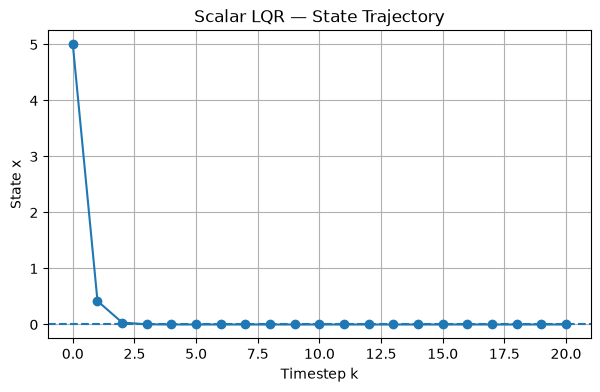

In [16]:
plt.figure(figsize=(7, 4))
plt.plot(range(N + 1), X, marker="o")
plt.axhline(0.0, linestyle="--")
plt.xlabel("Timestep k")
plt.ylabel("State x")
plt.title("Scalar LQR — State Trajectory")
plt.grid(True)
plt.show()

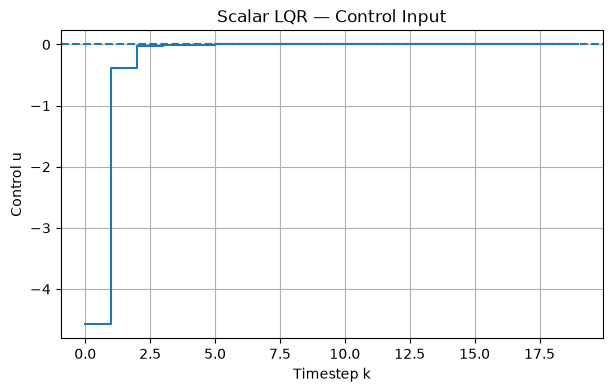

In [17]:
plt.figure(figsize=(7, 4))
plt.step(range(N), U, where="post")
plt.axhline(0.0, linestyle="--")
plt.xlabel("Timestep k")
plt.ylabel("Control u")
plt.title("Scalar LQR — Control Input")
plt.grid(True)
plt.show()

### Observation

The LQR controller applies strong corrective control when the state is far from zero.

As the state approaches the desired equilibrium,

$$
x_k \rightarrow 0,
$$

the control also approaches zero:

$$
u_k=-K_kx_k \rightarrow 0.
$$

Therefore, the controller naturally reduces its effort as the regulation error decreases.

The result illustrates the feedback structure:

$$
\boxed{
\text{state error}
\rightarrow
\text{feedback gain}
\rightarrow
\text{control action}
}
$$

## 13. Effect of the Control Weight

The LQR objective balances state error against control effort:

$$
J=
q_f x_N^2
+
\sum_{k=0}^{N-1}
\left(
q x_k^2+r u_k^2
\right).
$$

The weight $q$ determines how expensive state error is, while $r$ determines how expensive control effort is.

Therefore:

$$
q \uparrow
\quad\Rightarrow\quad
\text{stronger incentive to reduce state error}
$$

while:

$$
r \uparrow
\quad\Rightarrow\quad
\text{stronger incentive to avoid large control inputs}.
$$

We can compare different values of $r$ while keeping the system and state cost unchanged.

In [18]:
def scalar_lqr(a, b, q, r, q_f, N, x0):

    P = np.zeros(N + 1)
    K = np.zeros(N)

    P[N] = q_f

    # Backward pass
    for k in reversed(range(N)):

        K[k] = (
            a * b * P[k + 1]
            / (r + b**2 * P[k + 1])
        )

        P[k] = (
            q
            + a**2 * P[k + 1]
            - (
                a**2 * b**2 * P[k + 1]**2
                / (r + b**2 * P[k + 1])
            )
        )

    # Forward rollout
    X = np.zeros(N + 1)
    U = np.zeros(N)

    X[0] = x0

    for k in range(N):
        U[k] = -K[k] * X[k]
        X[k + 1] = a * X[k] + b * U[k]

    return X, U, P, K

In [19]:
X_low, U_low, _, _ = scalar_lqr(
    a, b, q, 0.1, q_f, N, x0
)

X_high, U_high, _, _ = scalar_lqr(
    a, b, q, 10.0, q_f, N, x0
)

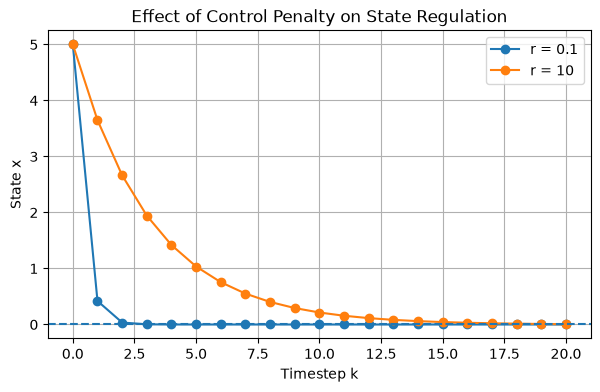

In [20]:
plt.figure(figsize=(7, 4))

plt.plot(X_low, marker="o", label="r = 0.1")
plt.plot(X_high, marker="o", label="r = 10")

plt.axhline(0.0, linestyle="--")

plt.xlabel("Timestep k")
plt.ylabel("State x")
plt.title("Effect of Control Penalty on State Regulation")
plt.legend()
plt.grid(True)
plt.show()

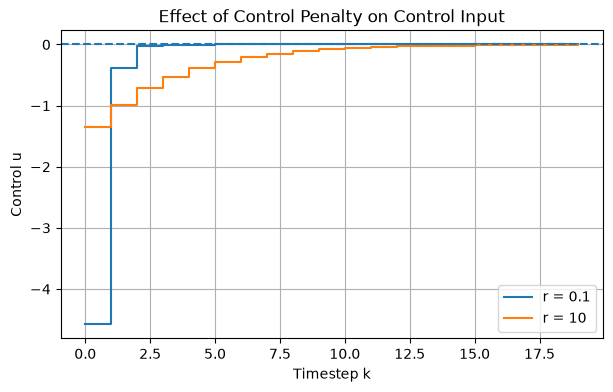

In [21]:
plt.figure(figsize=(7, 4))

plt.step(range(N), U_low, where="post", label="r = 0.1")
plt.step(range(N), U_high, where="post", label="r = 10")

plt.axhline(0.0, linestyle="--")

plt.xlabel("Timestep k")
plt.ylabel("Control u")
plt.title("Effect of Control Penalty on Control Input")
plt.legend()
plt.grid(True)
plt.show()

### Takeaway

The cost weights determine the behavior of the optimal controller.

A small control penalty allows stronger control actions:

$$
r \downarrow
\quad\Rightarrow\quad
\text{more aggressive regulation}.
$$

A large control penalty makes control expensive:

$$
r \uparrow
\quad\Rightarrow\quad
\text{smoother but slower regulation}.
$$

Therefore, LQR does not simply minimize state error.

It finds the optimal trade-off between:

$$
\boxed{
\text{state regulation}
\quad\text{and}\quad
\text{control effort}.
}
$$

## 14. From Scalar LQR to Matrix LQR

Real control systems usually contain multiple state and control variables.

We therefore replace the scalar dynamics:

$$
x_{k+1}=ax_k+bu_k
$$

with the linear system:

$$
\boxed{
x_{k+1}=Ax_k+Bu_k
}
$$

where:

$$
x_k \in \mathbb{R}^{n_x}
$$

is the state vector and:

$$
u_k \in \mathbb{R}^{n_u}
$$

is the control vector.

The scalar quadratic cost:

$$
qx_k^2+ru_k^2
$$

becomes:

$$
\boxed{
x_k^TQx_k+u_k^TRu_k
}
$$

and the terminal cost becomes:

$$
x_N^TQ_fx_N.
$$

Therefore, the finite-horizon objective is:

$$
\boxed{
J =
x_N^TQ_fx_N
+
\sum_{k=0}^{N-1}
\left(
x_k^TQx_k
+
u_k^TRu_k
\right).
}
$$

### Matrix Value Function

As in the scalar case, the terminal value function is quadratic:

$$
V_N(x)=x^TQ_fx.
$$

Therefore:

$$
P_N=Q_f.
$$

Assume that at timestep $k+1$:

$$
V_{k+1}(x)=x^TP_{k+1}x.
$$

Using the Bellman recursion:

$$
V_k(x)=
\min_u
\left[
x^TQx
+
u^TRu
+
V_{k+1}(Ax+Bu)
\right].
$$

Substituting the quadratic value function gives:

$$
V_k(x)=
\min_u
\left[
x^TQx
+
u^TRu
+
(Ax+Bu)^TP_{k+1}(Ax+Bu)
\right].
$$

### Optimal Feedback Gain

Minimizing the Bellman expression with respect to the control gives:

$$
\boxed{
K_k=
(R+B^TP_{k+1}B)^{-1}
B^TP_{k+1}A
}
$$

and therefore the optimal control law is:

$$
\boxed{
u_k^*=-K_kx_k.
}
$$

This is the matrix equivalent of the scalar feedback law derived previously.

The controller maps the current state vector directly to the optimal control vector.

### Discrete Riccati Recursion

Substituting the optimal feedback control back into the Bellman equation gives:

$$
\boxed{
P_k=Q+
A^TP_{k+1}A-
A^TP_{k+1}B
(R+B^TP_{k+1}B)^{-1}
B^TP_{k+1}A
}
$$

with terminal condition:

$$
P_N=Q_f.
$$

The finite-horizon LQR algorithm therefore performs:

$$
P_N
\rightarrow
(K_{N-1},P_{N-1})
\rightarrow
(K_{N-2},P_{N-2})
\rightarrow
\cdots
\rightarrow
(K_0,P_0).
$$

The resulting controller is then executed forward:

$$
u_k=-K_kx_k.
$$

## Case Study

### Vehicle Lateral Tracking with LQR

We now apply LQR to a simple vehicle path-tracking problem.

The requirement is:

> A vehicle is laterally displaced and misaligned from a straight reference path. Determine steering commands that bring the vehicle smoothly back to the reference.

Instead of describing the vehicle using global position, we describe its error relative to the desired path.

Define the state:

$$
x =
\begin{bmatrix}
e_y \\
e_\theta
\end{bmatrix}
$$

where:

- $e_y$ is the lateral position error,
- $e_\theta$ is the heading error relative to the path.

The control input is the steering angle:

$$
u=\delta.
$$

The desired state is therefore:

$$
\boxed{
x_{\text{desired}}=
\begin{bmatrix}
0\\
0
\end{bmatrix}
}
$$

which means that the vehicle is located on the reference path and aligned with it.

#### Linearized Vehicle Error Dynamics

The kinematic bicycle model is nonlinear.

For a straight reference path and small deviations, assume:

$$
\sin(e_\theta)\approx e_\theta
$$

and:

$$
\tan(\delta)\approx\delta.
$$

Assuming constant forward velocity $v$, the lateral error dynamics can then be approximated as:

$$
\dot e_y = v e_\theta
$$

and:

$$
\dot e_\theta = \frac{v}{L}\delta.
$$

In matrix form:

$$
\boxed{
\dot x = A_c x + B_c u
}
$$

with:

$$
A_c =
\begin{bmatrix}
0 & v\\
0 & 0
\end{bmatrix},
$$

and:

$$
B_c =
\begin{bmatrix}
0\\
\frac{v}{L}
\end{bmatrix}.
$$

#### Discrete Vehicle Model

The LQR formulation uses discrete dynamics:

$$
x_{k+1}=Ax_k+Bu_k.
$$

Using Forward Euler:

$$
x_{k+1}=
x_k
+
\Delta t
\left(
A_cx_k+B_cu_k
\right).
$$

Therefore:

$$
A=I+\Delta t A_c
$$

and:

$$
B=\Delta t B_c.
$$

For the vehicle model:

$$
\boxed{
A=
\begin{bmatrix}
1 & v\Delta t\\
0 & 1
\end{bmatrix}
}
$$

and:

$$
\boxed{
B=
\begin{bmatrix}
0\\
\frac{v\Delta t}{L}
\end{bmatrix}.
}
$$

The resulting discrete error dynamics are:

$$
\boxed{
x_{k+1}=Ax_k+B\delta_k.
}
$$

#### LQR Objective for Path Tracking

The controller should reduce:

- lateral position error,
- heading error,
- unnecessary steering effort.

Choose:

$$
Q=
\begin{bmatrix}
q_y & 0\\
0 & q_\theta
\end{bmatrix}
$$

and:

$$
R=
\begin{bmatrix}
r_\delta
\end{bmatrix}.
$$

For example:

$$
Q=
\begin{bmatrix}
10 & 0\\
0 & 5
\end{bmatrix},
\qquad
R=
\begin{bmatrix}
1
\end{bmatrix}.
$$

The running cost becomes:

$$
x_k^TQx_k+u_k^TRu_k
$$

or explicitly:

$$
\boxed{
10e_{y,k}^2
+
5e_{\theta,k}^2
+
\delta_k^2.
}
$$

Therefore, the LQR controller balances:

$$
\boxed{
\text{lateral tracking}
+
\text{heading alignment}
+
\text{steering effort}.
}
$$

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Vehicle / simulation parameters
v = 5.0          # constant forward speed [m/s]
L = 2.5          # wheelbase [m]
dt = 0.1         # timestep [s]
N = 80           # horizon

# Discrete linearized dynamics
A = np.array([
    [1.0, v * dt],
    [0.0, 1.0]
])

B = np.array([
    [0.0],
    [v * dt / L]
])

# Cost matrices
Q = np.diag([10.0, 5.0])
R = np.array([[1.0]])
Qf = np.diag([20.0, 10.0])

# Initial tracking error:
# 1.5 m lateral offset, 10 degree heading error
x0 = np.array([
    1.5,
    np.deg2rad(10.0)
])

### Vehicle LQR Implementation

We consider a vehicle moving at constant forward speed:

$$
v = 5 \text{ m/s}
$$

with wheelbase:

$$
L = 2.5 \text{ m}.
$$

The timestep is:

$$
\Delta t = 0.1 \text{ s}.
$$

Using the linearized error dynamics, the discrete system matrices are:

$$
A=
\begin{bmatrix}
1 & v\Delta t\\
0 & 1
\end{bmatrix}
$$

and:

$$
B=
\begin{bmatrix}
0\\
\frac{v\Delta t}{L}
\end{bmatrix}.
$$

The initial tracking error is chosen as:

$$
e_y(0)=1.5\text{ m}
$$

and:

$$
e_\theta(0)=10^\circ.
$$

The controller must bring both errors toward zero.

In [23]:
nx = A.shape[0]
nu = B.shape[1]

P = np.zeros((N + 1, nx, nx))
K = np.zeros((N, nu, nx))

P[N] = Qf

for k in reversed(range(N)):

    S = R + B.T @ P[k + 1] @ B

    K[k] = (
        np.linalg.solve(
            S,
            B.T @ P[k + 1] @ A
        )
    )

    P[k] = (
        Q
        + A.T @ P[k + 1] @ A
        - A.T @ P[k + 1] @ B @ K[k]
    )

In [24]:
X = np.zeros((N + 1, nx))
U = np.zeros((N, nu))

X[0] = x0

for k in range(N):

    U[k] = -K[k] @ X[k]

    X[k + 1] = (
        A @ X[k]
        + B @ U[k]
    )

#### Forward Feedback Control

After computing the gains $K_k$, the controller is executed forward.

At each timestep:

$$
u_k=-K_kx_k.
$$

For this vehicle model:

$$
\delta_k=
-K_k
\begin{bmatrix}
e_{y,k}\\
e_{\theta,k}
\end{bmatrix}.
$$

The next tracking-error state is then:

$$
x_{k+1}=Ax_k+B\delta_k.
$$

The controller therefore continuously uses the current lateral and heading errors to determine the steering command.

#### Plot the Errors

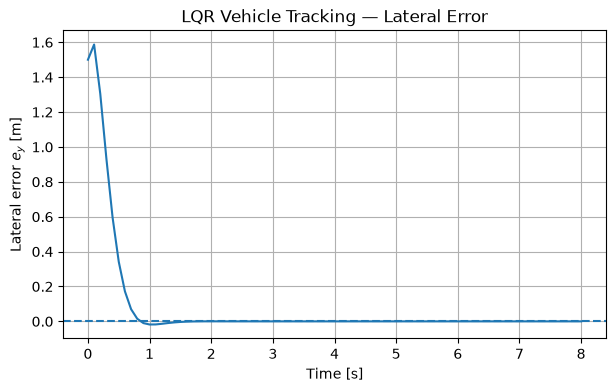

In [25]:
time = np.arange(N + 1) * dt

plt.figure(figsize=(7, 4))
plt.plot(time, X[:, 0])
plt.axhline(0.0, linestyle="--")
plt.xlabel("Time [s]")
plt.ylabel("Lateral error $e_y$ [m]")
plt.title("LQR Vehicle Tracking — Lateral Error")
plt.grid(True)
plt.show()

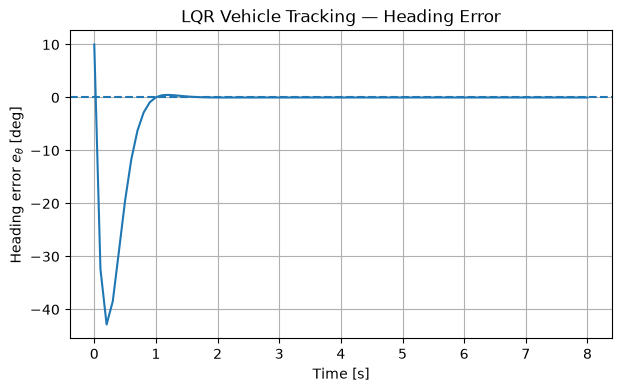

In [26]:
plt.figure(figsize=(7, 4))
plt.plot(time, np.rad2deg(X[:, 1]))
plt.axhline(0.0, linestyle="--")
plt.xlabel("Time [s]")
plt.ylabel("Heading error $e_\\theta$ [deg]")
plt.title("LQR Vehicle Tracking — Heading Error")
plt.grid(True)
plt.show()

### Observation

The LQR controller drives both tracking errors toward zero:

$$
e_y \rightarrow 0
$$

and:

$$
e_\theta \rightarrow 0.
$$

The steering command is strongest while the vehicle is significantly displaced or misaligned.

As the vehicle approaches the reference path:

$$
x_k \rightarrow 0,
$$

the feedback law:

$$
u_k=-K_kx_k
$$

naturally produces:

$$
u_k \rightarrow 0.
$$

This demonstrates how LQR converts the tracking-error state directly into a stabilizing feedback control action.

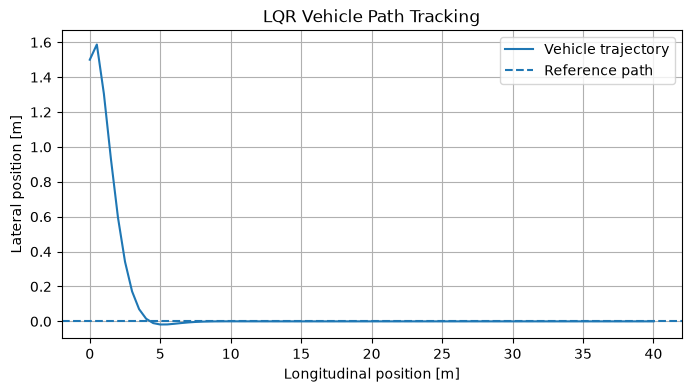

In [27]:
px = v * time
py = X[:, 0]

plt.figure(figsize=(8, 4))

plt.plot(px, py, label="Vehicle trajectory")
plt.axhline(0.0, linestyle="--", label="Reference path")

plt.xlabel("Longitudinal position [m]")
plt.ylabel("Lateral position [m]")
plt.title("LQR Vehicle Path Tracking")
plt.legend()
plt.grid(True)
plt.show()

## 15. Finite-Horizon vs Infinite-Horizon LQR

In finite-horizon LQR, the feedback gain depends on the timestep:

$$
u_k=-K_kx_k.
$$

This happens because the controller knows that only a limited number of steps remain.

Near the end of the horizon, the terminal cost $Q_f$ influences the solution strongly.

For a sufficiently long horizon, however, the Riccati matrices often converge away from the terminal boundary:

$$
P_k \approx P
$$

and therefore:

$$
K_k \approx K.
$$

The controller then approaches a time-invariant feedback law:

$$
\boxed{
u_k=-Kx_k
}
$$

This motivates the infinite-horizon LQR formulation.

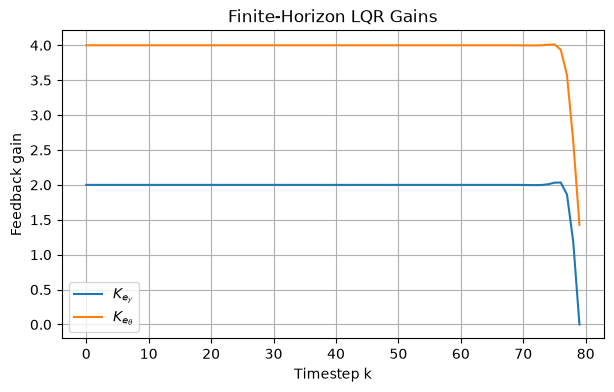

In [28]:
plt.figure(figsize=(7, 4))

plt.plot(range(N), K[:, 0, 0], label="$K_{e_y}$")
plt.plot(range(N), K[:, 0, 1], label="$K_{e_\\theta}$")

plt.xlabel("Timestep k")
plt.ylabel("Feedback gain")
plt.title("Finite-Horizon LQR Gains")
plt.legend()
plt.grid(True)
plt.show()

### Infinite-Horizon LQR

Consider the objective:

$$
J
=\sum_{k=0}^{\infty}
\left(
x_k^TQx_k
+
u_k^TRu_k
\right).
$$

For a time-invariant linear system:

$$
x_{k+1}=Ax_k+Bu_k,
$$

the value function can converge to a time-independent quadratic form:

$$
\boxed{
V(x)=x^TPx.
}
$$

The Riccati recursion then reaches a fixed point:

$$
P_k=P_{k+1}=P.
$$

Substituting this into the discrete Riccati recursion gives the **Discrete Algebraic Riccati Equation (DARE)**:

$$
\boxed{
P=Q
+
A^TPA-
A^TPB
(R+B^TPB)^{-1}
B^TPA.
}
$$

The corresponding feedback gain is:

$$
\boxed{
K=
(R+B^TPB)^{-1}B^TPA.
}
$$

The resulting controller is stationary:

$$
\boxed{
u_k=-Kx_k.
}
$$

In [29]:
from scipy.linalg import solve_discrete_are

P_inf = solve_discrete_are(A, B, Q, R)

K_inf = np.linalg.solve(
    R + B.T @ P_inf @ B,
    B.T @ P_inf @ A
)

print("Infinite-horizon P:")
print(P_inf)

print("\nInfinite-horizon K:")
print(K_inf)

print("\nFinite-horizon K at k=0:")
print(K[0])

Infinite-horizon P:
[[40.  25. ]
 [25.  37.5]]

Infinite-horizon K:
[[2. 4.]]

Finite-horizon K at k=0:
[[2. 4.]]


### Observation

For a sufficiently long finite horizon, the early feedback gains approach the infinite-horizon gain:

$$
K_k \rightarrow K.
$$

The infinite-horizon controller therefore uses one constant feedback matrix:

$$
u=-Kx.
$$

This is a stationary policy because the same state always produces the same control action, independent of timestep.

The finite-horizon controller instead uses:

$$
u_k=-K_kx_k,
$$

so its policy is time-dependent.

## 16. Dynamic Programming vs LQR

Dynamic Programming provides a general framework for sequential decision-making.

For deterministic dynamics:

$$
x_{k+1}=f(x_k,u_k),
$$

the Bellman recursion is:

$$
\boxed{
V_k(x)=
\min_u
\left[
\ell(x,u)
+
V_{k+1}(f(x,u))
\right].
}
$$

In the small discrete example, the value function was explicitly stored for individual states.

This becomes computationally expensive for large or continuous state spaces.

LQR considers the special case of:

$$
x_{k+1}=Ax_k+Bu_k
$$

with quadratic cost:

$$
\ell(x,u)=x^TQx+u^TRu.
$$

For this structure, the value function is quadratic:

$$
\boxed{
V_k(x)=x^TP_kx.
}
$$

Therefore, instead of explicitly storing the value of every possible state, the value function is represented compactly by the matrix $P_k$.

The corresponding optimal policy is also compact:

$$
\boxed{
u_k=-K_kx_k.
}
$$

### Computational View

For grid-based Dynamic Programming:

$$
\boxed{
\text{state}
\rightarrow
\text{lookup }V_k(x)
\rightarrow
\text{lookup }\pi_k(x)
}
$$

The number of states can grow exponentially with state dimension.

For LQR:

$$
\boxed{
V_k(x)=x^TP_kx
}
$$

and:

$$
\boxed{
\pi_k(x)=-K_kx.
}
$$

The matrices $P_k$ and $K_k$ provide compact representations of the value function and policy.

This efficiency is possible because LQR exploits the special structure of:

$$
\boxed{
\text{linear dynamics + quadratic cost}.
}
$$

## 17. Takeaway

This notebook introduced Dynamic Programming as a different way of organizing finite-horizon optimal control problems.

The main progression was:

$$
\boxed{
\text{finite-horizon control problem}
\rightarrow
\text{repeated subproblems}
\rightarrow
\text{value function}
\rightarrow
\text{Bellman recursion}
\rightarrow
\text{optimal policy}.
}
$$

The value function represents optimal future cost:

$$
V_k(x)=
\text{optimal cost-to-go from }x.
$$

The policy determines the optimal action:

$$
u_k=\pi_k(x_k).
$$

For general grid-based Dynamic Programming, explicitly representing the value function becomes difficult as the state dimension increases:

$$
\boxed{
\text{curse of dimensionality}.
}
$$

For linear dynamics:

$$
x_{k+1}=Ax_k+Bu_k
$$

and quadratic costs:

$$
x^TQx+u^TRu,
$$

the value function has the compact form:

$$
\boxed{
V_k(x)=x^TP_kx.
}
$$

Dynamic Programming then produces the Riccati recursion and the LQR feedback policy:

$$
\boxed{
u_k=-K_kx_k.
}
$$

For finite-horizon LQR, $K_k$ is generally time-dependent.

For infinite-horizon LQR, the Riccati recursion can converge to a fixed point, producing a stationary feedback policy:

$$
\boxed{
u=-Kx.
}
$$

The vehicle example demonstrated how LQR can regulate lateral and heading errors:

$$
x=
\begin{bmatrix}
e_y\\
e_\theta
\end{bmatrix}
\rightarrow
\begin{bmatrix}
0\\
0
\end{bmatrix}
$$

while balancing tracking accuracy against steering effort.

The central connection is:

$$
\boxed{
P_k
\leftrightarrow
\text{value function}
}
$$

and:

$$
\boxed{
K_k
\leftrightarrow
\text{feedback policy}.
}
$$